# 01 – Data Collection & EDA Awal
**Proyek Capstone – Sistem Deteksi Anomali Kualitas Udara**  
**Kelompok Aeris | SDT PENS 2026**  
**PIC: Linda Anggara Wati – Data, EDA, Feature Engineering & ML**

---
**Minggu 1 | 27 April – 3 Mei 2026**  
Fase: Phase 1 – Problem Understanding & Data Collection

**Checklist Minggu 1 (Linda):**
- [x] Setup environment Python
- [x] Fetch data historis Open-Meteo: 1 Jan 2026 – sekarang
- [x] Fetch data meteorologi (suhu, kelembaban, angin, hujan)
- [x] Simpan raw data ke CSV lokal (data/raw/)
- [x] Eksplorasi awal: shape, tipe data, statistik deskriptif
- [x] Identifikasi missing values per kolom dan per bulan
- [x] Analisis distribusi tiap polutan (PM2.5, PM10, CO, NO2, O3)
- [x] Studi literatur: formula ISPU KLHK (Permen LHK No.14/2020)

**Sumber data:** Open-Meteo Air Quality API (gratis, tanpa API key)  
**Koordinat Surabaya:** latitude -7.2575, longitude 112.7521  
**Rentang data:** 1 Januari 2026 – H-1 sebelum demo

## 1. Setup Environment

In [1]:
# Install dependencies (jalankan sekali)
!pip install requests pandas matplotlib seaborn -q


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\ADVAN\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta

# Style visualisasi
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(ROOT)

# Buat folder struktur project
for folder in ["data/raw", "data/processed", "models", "reports", "notebooks"]:
    os.makedirs(folder, exist_ok=True)

print("✅ Environment siap")
print("Folder yang dibuat:", os.listdir("."))

✅ Environment siap
Folder yang dibuat: ['.env', '.env.example', '.git', '.gitignore', 'data', 'env', 'LICENSE', 'logs.log', 'Makefile', 'mlflow.db', 'mlruns', 'models', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'src']


## 2. Fetch Data Historis – Polutan Udara (Jan 2026 – Sekarang)
**Sumber:** Open-Meteo Air Quality API  
**Parameter polutan:** PM2.5, PM10, CO, NO2, O3

In [3]:
# Konfigurasi
LAT        = -7.2575
LON        = 112.7521
START_DATE = "2026-01-01"
END_DATE   = (datetime.today() - timedelta(days=1)).strftime("%Y-%m-%d")  # H-1

print(f"Rentang data: {START_DATE} → {END_DATE}")

# Fetch air quality
resp_aq = requests.get(
    "https://air-quality-api.open-meteo.com/v1/air-quality",
    params={
        "latitude"  : LAT,
        "longitude" : LON,
        "hourly"    : [
            "pm2_5", "pm10",
            "carbon_monoxide",
            "nitrogen_dioxide",
            "ozone"
        ],
        "timezone"   : "Asia/Jakarta",
        "start_date" : START_DATE,
        "end_date"   : END_DATE,
    }
)
resp_aq.raise_for_status()

df_aq = pd.DataFrame(resp_aq.json()["hourly"])
df_aq["time"] = pd.to_datetime(df_aq["time"])

print(f"\n✅ Data polutan berhasil di-fetch")
print(f"   Dari : {df_aq['time'].iloc[0]}")
print(f"   s/d  : {df_aq['time'].iloc[-1]}")
print(f"   Total: {len(df_aq):,} baris | {df_aq.shape[1]} kolom")
df_aq.head()

Rentang data: 2026-01-01 → 2026-05-17

✅ Data polutan berhasil di-fetch
   Dari : 2026-01-01 00:00:00
   s/d  : 2026-05-17 23:00:00
   Total: 3,288 baris | 6 kolom


,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,ozone
0,2026-01-01 00:00:00,100.4,100.6,961.0,79.6,3.0
1,2026-01-01 01:00:00,110.1,110.6,832.0,77.6,3.0
2,2026-01-01 02:00:00,116.9,118.3,657.0,75.2,1.0
3,2026-01-01 03:00:00,123.4,125.3,507.0,72.6,0.0
4,2026-01-01 04:00:00,136.0,137.4,582.0,70.2,2.0


## 3. Fetch Data Meteorologi (Suhu, Kelembaban, Angin, Hujan)

In [4]:
resp_w = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude"  : LAT,
        "longitude" : LON,
        "hourly"    : [
            "temperature_2m",
            "relative_humidity_2m",
            "wind_speed_10m",
            "wind_direction_10m",
            "precipitation"
        ],
        "timezone"   : "Asia/Jakarta",
        "start_date" : START_DATE,
        "end_date"   : END_DATE,
    }
)
resp_w.raise_for_status()

df_w = pd.DataFrame(resp_w.json()["hourly"])
df_w["time"] = pd.to_datetime(df_w["time"])
# rename supaya konsisten
df_w.rename(columns={"relative_humidity_2m": "relative_humidity"}, inplace=True)

print(f"✅ Data meteorologi berhasil di-fetch")
print(f"   Total: {len(df_w):,} baris | {df_w.shape[1]} kolom")
df_w.head()

✅ Data meteorologi berhasil di-fetch
   Total: 3,288 baris | 6 kolom


,time,temperature_2m,relative_humidity,wind_speed_10m,wind_direction_10m,precipitation
0,2026-01-01 00:00:00,25.7,84,7.6,277,0.0
1,2026-01-01 01:00:00,25.4,87,6.9,295,0.0
2,2026-01-01 02:00:00,25.0,89,6.7,284,0.0
3,2026-01-01 03:00:00,24.9,90,6.7,273,0.0
4,2026-01-01 04:00:00,24.8,92,7.8,266,0.0


## 4. Merge & Simpan Raw Data ke CSV

In [5]:
# Gabungkan polutan + meteorologi berdasarkan timestamp
df_raw = pd.merge(df_aq, df_w, on="time", how="inner")

# Rename kolom agar sesuai spesifikasi
df_raw.rename(columns={
    "pm2_5"            : "pm25",
    "carbon_monoxide"  : "co",
    "nitrogen_dioxide" : "no2",
    "ozone"            : "o3",
}, inplace=True)

# Simpan raw ke CSV
raw_path = "data/raw/surabaya_airquality_raw.csv"
df_raw.to_csv(raw_path, index=False)

print(f"✅ Raw data tersimpan → {raw_path}")
print(f"   Shape : {df_raw.shape}")
print(f"   Kolom : {list(df_raw.columns)}")
df_raw.head()

✅ Raw data tersimpan → data/raw/surabaya_airquality_raw.csv
   Shape : (3288, 11)
   Kolom : ['time', 'pm25', 'pm10', 'co', 'no2', 'o3', 'temperature_2m', 'relative_humidity', 'wind_speed_10m', 'wind_direction_10m', 'precipitation']


,time,pm25,pm10,co,no2,o3,temperature_2m,relative_humidity,wind_speed_10m,wind_direction_10m,precipitation
0,2026-01-01 00:00:00,100.4,100.6,961.0,79.6,3.0,25.7,84,7.6,277,0.0
1,2026-01-01 01:00:00,110.1,110.6,832.0,77.6,3.0,25.4,87,6.9,295,0.0
2,2026-01-01 02:00:00,116.9,118.3,657.0,75.2,1.0,25.0,89,6.7,284,0.0
3,2026-01-01 03:00:00,123.4,125.3,507.0,72.6,0.0,24.9,90,6.7,273,0.0
4,2026-01-01 04:00:00,136.0,137.4,582.0,70.2,2.0,24.8,92,7.8,266,0.0


## 5. Eksplorasi Awal – Shape, Tipe Data, Statistik Deskriptif

In [6]:
print("=" * 55)
print("5.1  INFO DATASET")
print("=" * 55)
print(f"Shape   : {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")
print(f"Rentang : {df_raw['time'].min()}  →  {df_raw['time'].max()}")
print()
df_raw.info()

5.1  INFO DATASET
Shape   : 3,288 baris × 11 kolom
Rentang : 2026-01-01 00:00:00  →  2026-05-17 23:00:00

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3288 entries, 0 to 3287
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   time                3288 non-null   datetime64[ns]
 1   pm25                3288 non-null   float64       
 2   pm10                3288 non-null   float64       
 3   co                  3288 non-null   float64       
 4   no2                 3288 non-null   float64       
 5   o3                  3288 non-null   float64       
 6   temperature_2m      3288 non-null   float64       
 7   relative_humidity   3288 non-null   int64         
 8   wind_speed_10m      3288 non-null   float64       
 9   wind_direction_10m  3288 non-null   int64         
 10  precipitation       3288 non-null   float64       
dtypes: datetime64[ns](1), float64(8), int64(2)
memory usag

In [7]:
print("=" * 55)
print("5.2  STATISTIK DESKRIPTIF")
print("=" * 55)
polutan_cols = ["pm25", "pm10", "co", "no2", "o3"]
meteo_cols   = ["temperature_2m", "relative_humidity",
                "wind_speed_10m", "wind_direction_10m", "precipitation"]

print("\n--- Polutan ---")
display(df_raw[polutan_cols].describe().round(2))

print("\n--- Meteorologi ---")
display(df_raw[meteo_cols].describe().round(2))

5.2  STATISTIK DESKRIPTIF

--- Polutan ---


,pm25,pm10,co,no2,o3
count,3288.00,3288.00,3288.0,3288.00,3288.00
mean,37.61,38.45,1367.3,34.65,67.12
std,21.54,21.77,1045.0,21.28,53.60
min,6.10,6.30,35.0,2.70,0.00
25%,22.68,23.30,604.0,18.40,25.00
50%,32.20,33.20,1044.5,31.20,50.00
75%,46.40,47.50,1813.5,47.52,103.00
max,148.10,150.40,8115.0,193.40,284.00



--- Meteorologi ---


,temperature_2m,relative_humidity,wind_speed_10m,wind_direction_10m,precipitation
count,3288.00,3288.00,3288.00,3288.00,3288.00
mean,27.67,78.92,8.65,221.78,0.27
std,2.36,11.88,4.35,87.02,0.81
min,23.50,35.00,0.00,4.00,0.00
25%,25.60,71.00,5.30,125.00,0.00
50%,27.40,81.00,8.10,267.00,0.00
75%,29.50,88.00,11.60,287.00,0.10
max,34.30,98.00,25.50,360.00,10.20


## 6. Identifikasi Missing Values

In [8]:
print("=" * 55)
print("6.  MISSING VALUES")
print("=" * 55)

missing = df_raw.isnull().sum().rename("total_missing")
missing_pct = (df_raw.isnull().mean() * 100).rename("pct_missing").round(2)
mv_df = pd.concat([missing, missing_pct], axis=1)
mv_df = mv_df[mv_df["total_missing"] > 0].sort_values("total_missing", ascending=False)

if mv_df.empty:
    print("✅ Tidak ada missing values!")
else:
    print(mv_df)

# Missing values per bulan (per polutan)
print("\n--- Missing per Bulan (PM2.5) ---")
df_raw["bulan"] = df_raw["time"].dt.to_period("M")
mv_bulan = df_raw.groupby("bulan")["pm25"].apply(lambda x: x.isnull().sum())
print(mv_bulan)

6.  MISSING VALUES
✅ Tidak ada missing values!

--- Missing per Bulan (PM2.5) ---
bulan
2026-01    0
2026-02    0
2026-03    0
2026-04    0
2026-05    0
Freq: M, Name: pm25, dtype: int64


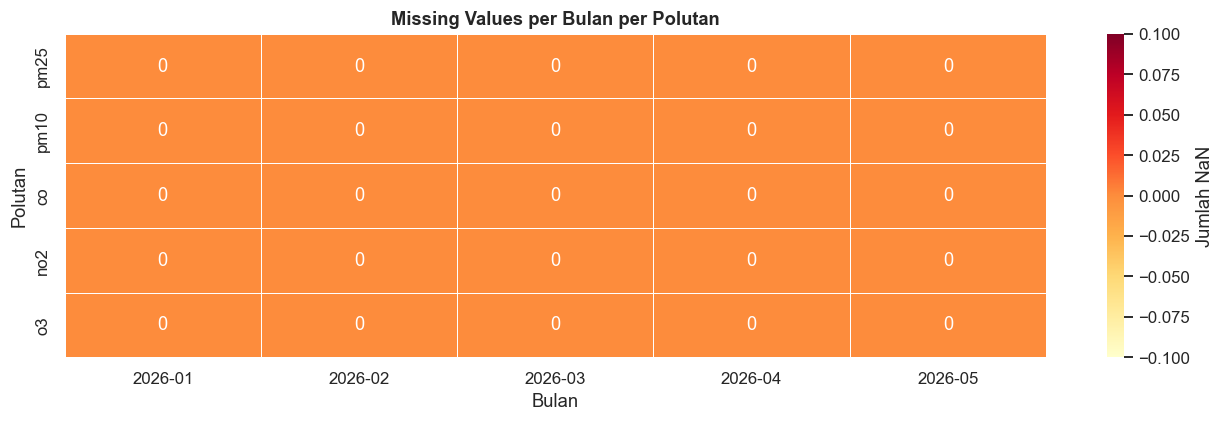

💾 Gambar disimpan → reports/missing_values_heatmap.png


In [9]:
# Visualisasi missing values — heatmap per bulan
fig, ax = plt.subplots(figsize=(12, 4))

mv_monthly = df_raw.groupby("bulan")[polutan_cols].apply(lambda g: g.isnull().sum())
sns.heatmap(mv_monthly.T, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Jumlah NaN"})
ax.set_title("Missing Values per Bulan per Polutan", fontweight="bold")
ax.set_xlabel("Bulan")
ax.set_ylabel("Polutan")
plt.tight_layout()
plt.savefig("reports/missing_values_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()
print("💾 Gambar disimpan → reports/missing_values_heatmap.png")

## 7. Analisis Distribusi Polutan (5 Visualisasi EDA)

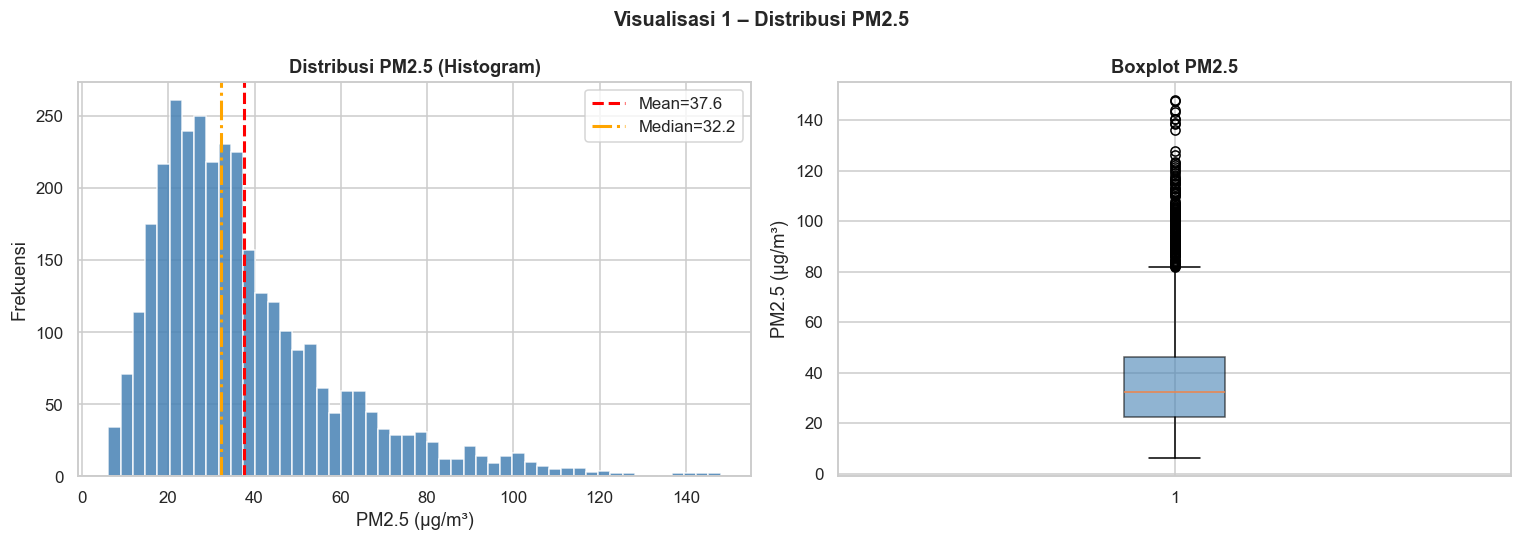

💾 Disimpan → reports/viz1_distribusi_pm25.png


In [10]:
# ── Visualisasi 1: Distribusi PM2.5 ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(df_raw["pm25"].dropna(), bins=50, color="steelblue",
         edgecolor="white", alpha=0.85)
ax1.axvline(df_raw["pm25"].mean(),  color="red",    lw=2, ls="--", label=f"Mean={df_raw['pm25'].mean():.1f}")
ax1.axvline(df_raw["pm25"].median(), color="orange", lw=2, ls="-.", label=f"Median={df_raw['pm25'].median():.1f}")
ax1.set_title("Distribusi PM2.5 (Histogram)", fontweight="bold")
ax1.set_xlabel("PM2.5 (µg/m³)"); ax1.set_ylabel("Frekuensi")
ax1.legend()

# Boxplot
ax2.boxplot(df_raw["pm25"].dropna(), vert=True, patch_artist=True,
            boxprops=dict(facecolor="steelblue", alpha=0.6))
ax2.set_title("Boxplot PM2.5", fontweight="bold")
ax2.set_ylabel("PM2.5 (µg/m³)")

plt.suptitle("Visualisasi 1 – Distribusi PM2.5", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/viz1_distribusi_pm25.png", dpi=110, bbox_inches="tight")
plt.show()
print("💾 Disimpan → reports/viz1_distribusi_pm25.png")

C:\Users\ADVAN\AppData\Local\Temp\ipykernel_35372\1960882678.py:22: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADVAN\AppData\Local\Temp\ipykernel_35372\1960882678.py:22: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADVAN\AppData\Local\Temp\ipykernel_35372\1960882678.py:23: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig("reports/viz2_distribusi_semua_polutan.png", dpi=110, bbox_inches="tight")
C:\Users\ADVAN\AppData\Local\Temp\ipykernel_35372\1960882678.py:23: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.savefig("reports/viz2_distribusi_semua_polutan.png", dpi=110, bbox_inches="tight")
C:\Users\ADVAN\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users

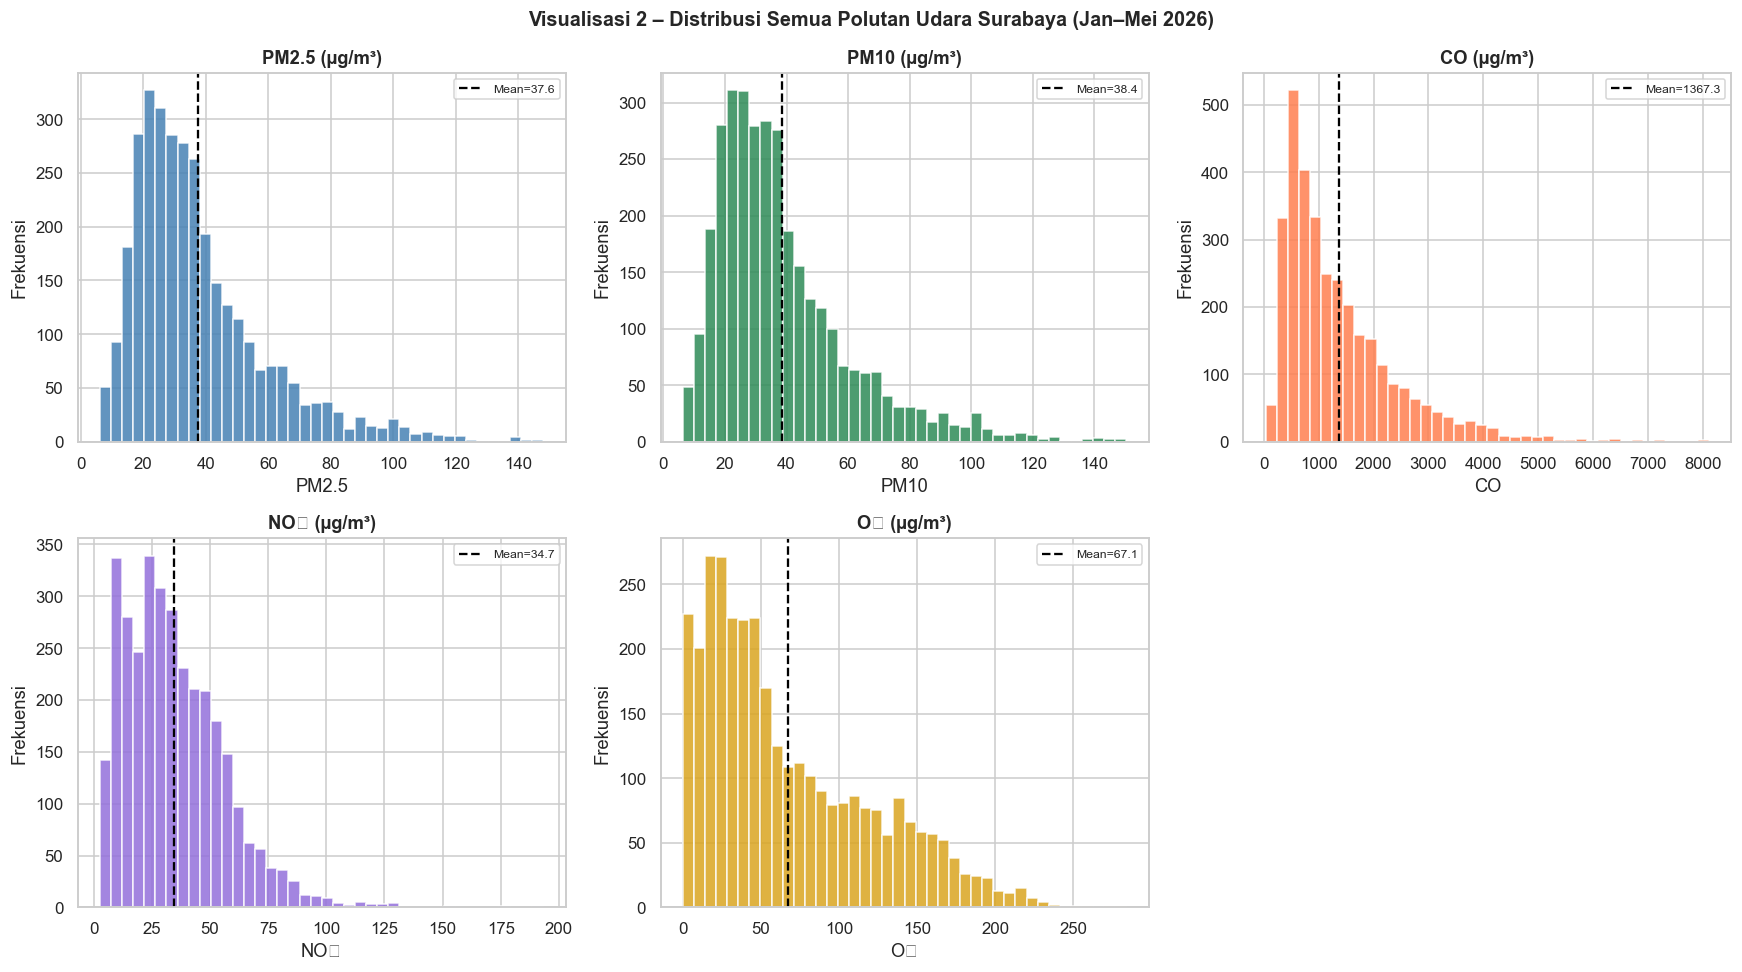

💾 Disimpan → reports/viz2_distribusi_semua_polutan.png


In [11]:
# ── Visualisasi 2: Distribusi semua polutan (Histogram grid) ────
labels_map = {"pm25": "PM2.5 (µg/m³)", "pm10": "PM10 (µg/m³)",
              "co": "CO (µg/m³)", "no2": "NO₂ (µg/m³)", "o3": "O₃ (µg/m³)"}
colors     = ["steelblue", "seagreen", "coral", "mediumpurple", "goldenrod"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (col, label) in enumerate(labels_map.items()):
    data_col = df_raw[col].dropna()
    axes[i].hist(data_col, bins=40, color=colors[i], edgecolor="white", alpha=0.85)
    axes[i].axvline(data_col.mean(), color="black", lw=1.5, ls="--",
                    label=f"Mean={data_col.mean():.1f}")
    axes[i].set_title(label, fontweight="bold")
    axes[i].set_xlabel(label.split(" ")[0])
    axes[i].set_ylabel("Frekuensi")
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)  # sembunyikan subplot kosong
plt.suptitle("Visualisasi 2 – Distribusi Semua Polutan Udara Surabaya (Jan–Mei 2026)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/viz2_distribusi_semua_polutan.png", dpi=110, bbox_inches="tight")
plt.show()
print("💾 Disimpan → reports/viz2_distribusi_semua_polutan.png")

C:\Users\ADVAN\AppData\Local\Temp\ipykernel_35372\826480160.py:15: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADVAN\AppData\Local\Temp\ipykernel_35372\826480160.py:15: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADVAN\AppData\Local\Temp\ipykernel_35372\826480160.py:16: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig("reports/viz3_timeseries_polutan.png", dpi=110, bbox_inches="tight")
C:\Users\ADVAN\AppData\Local\Temp\ipykernel_35372\826480160.py:16: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.savefig("reports/viz3_timeseries_polutan.png", dpi=110, bbox_inches="tight")


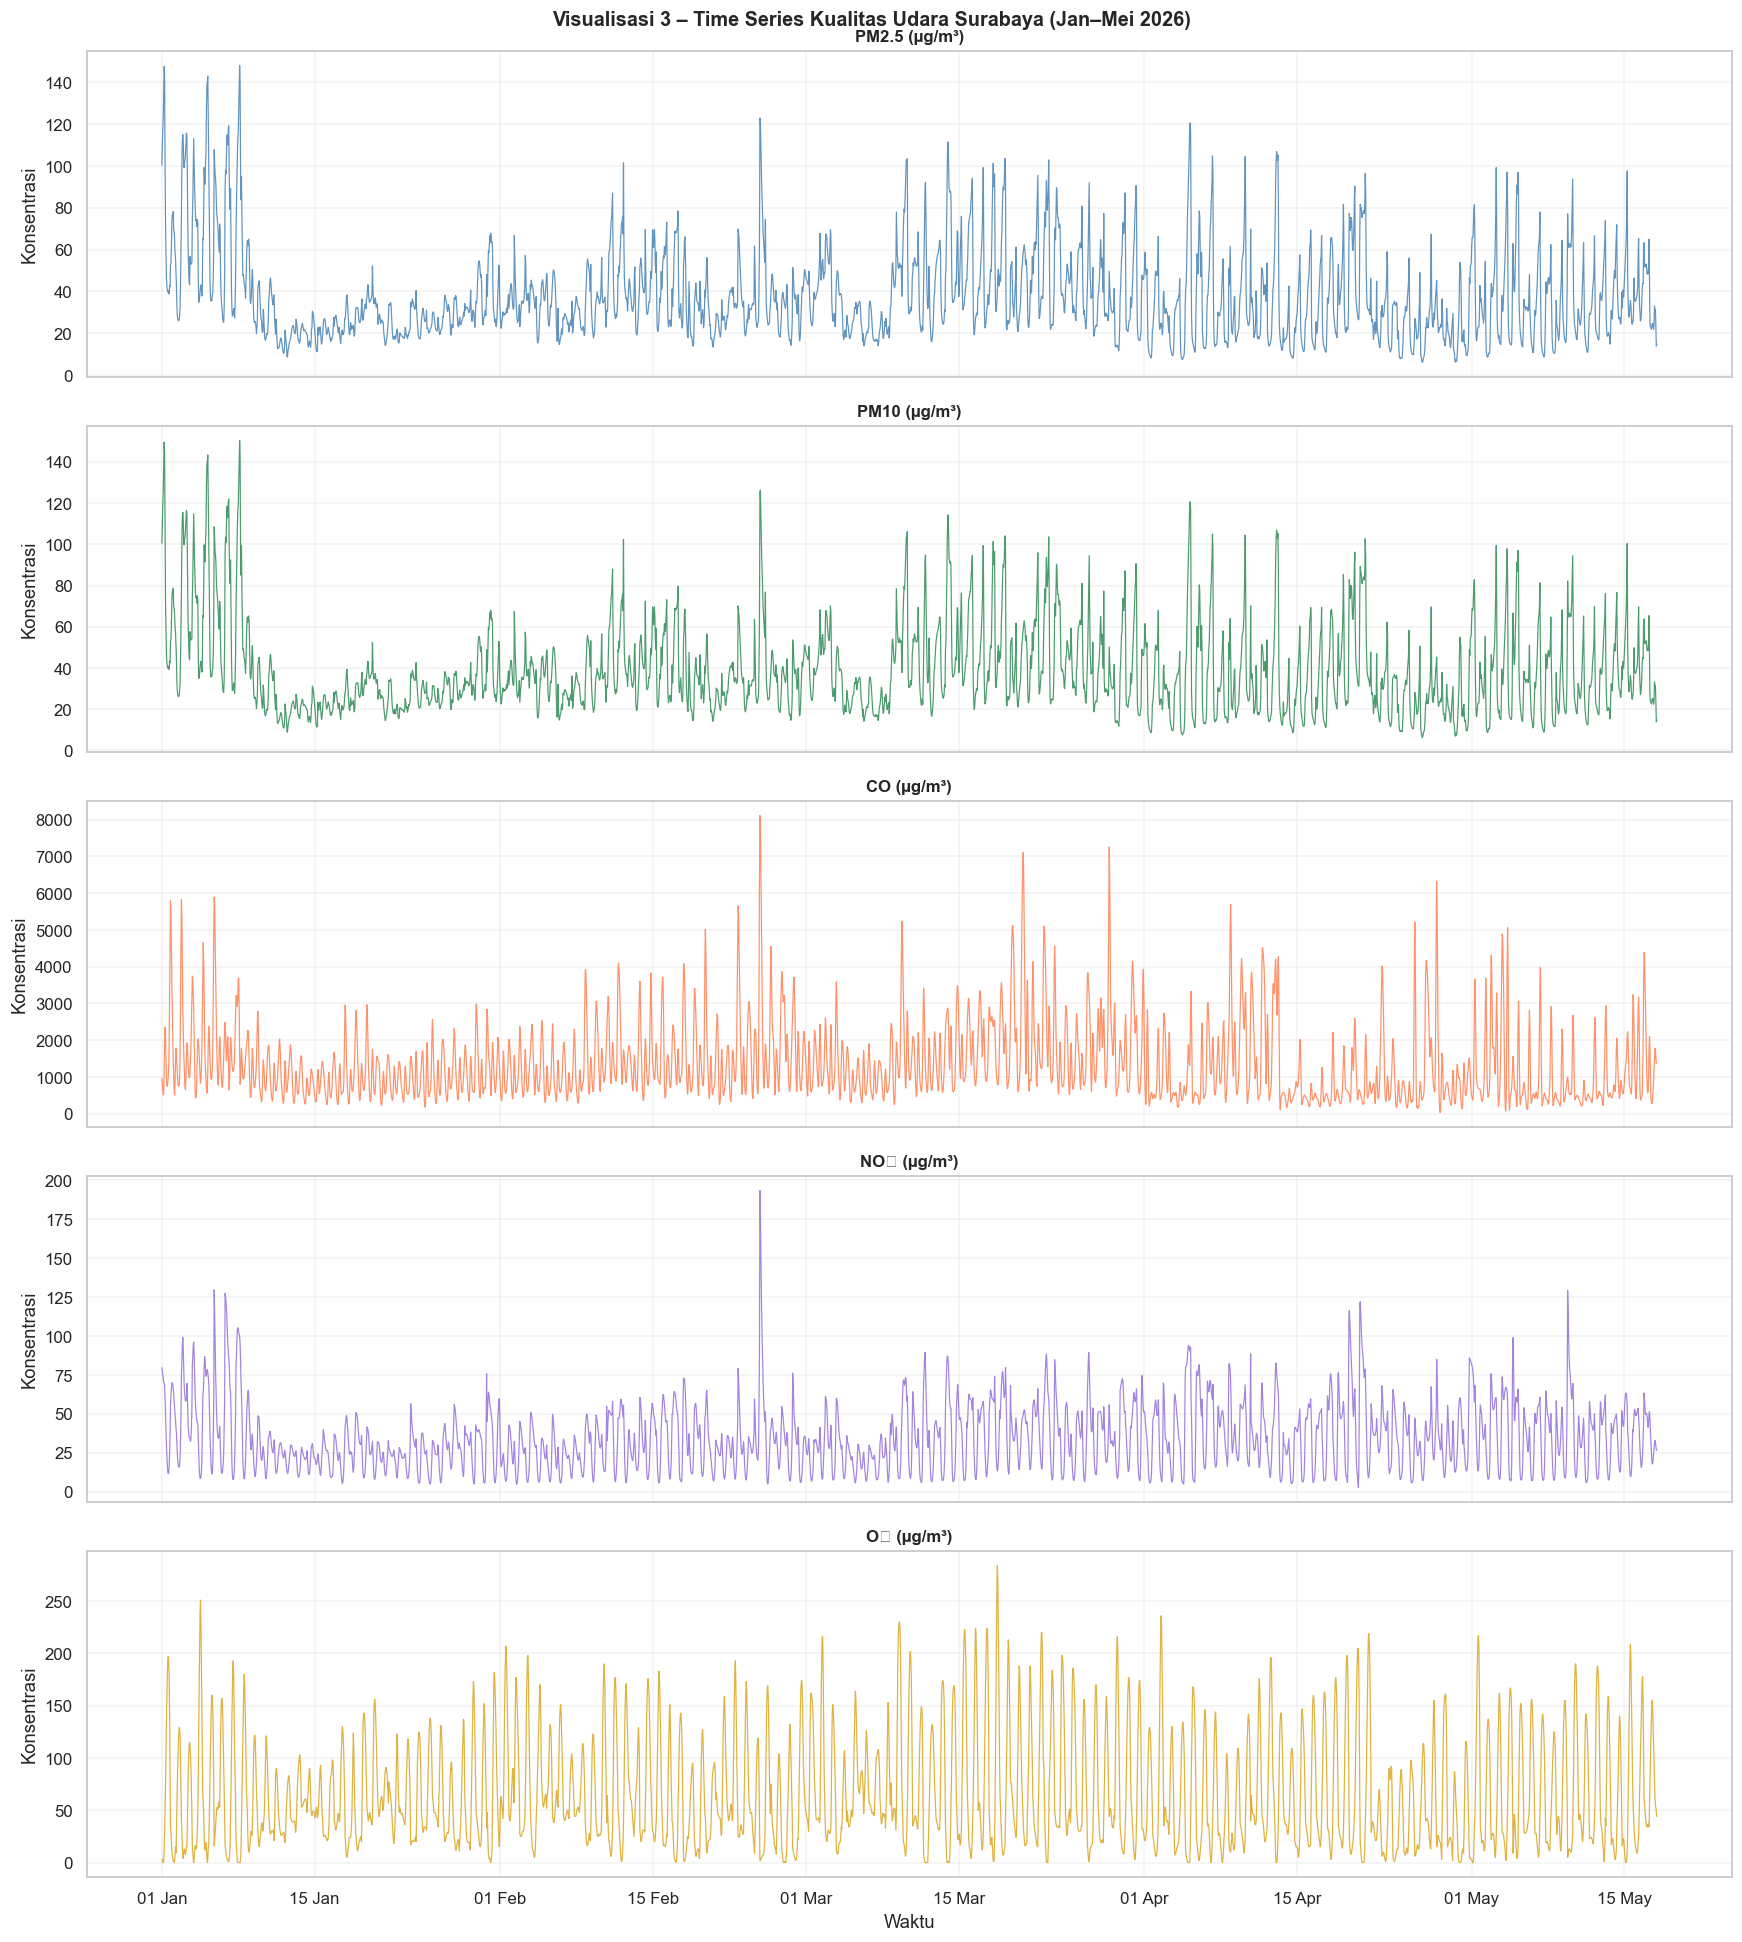

💾 Disimpan → reports/viz3_timeseries_polutan.png


In [12]:
# ── Visualisasi 3: Time-series semua polutan ─────────────────────
fig, axes = plt.subplots(5, 1, figsize=(16, 18), sharex=True)

for ax, (col, label), color in zip(axes, labels_map.items(), colors):
    ax.plot(df_raw["time"], df_raw[col],
            color=color, linewidth=0.8, alpha=0.85)
    ax.set_title(label, fontweight="bold", fontsize=11)
    ax.set_ylabel("Konsentrasi")
    ax.grid(True, alpha=0.25)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
axes[-1].set_xlabel("Waktu")
plt.suptitle("Visualisasi 3 – Time Series Kualitas Udara Surabaya (Jan–Mei 2026)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/viz3_timeseries_polutan.png", dpi=110, bbox_inches="tight")
plt.show()
print("💾 Disimpan → reports/viz3_timeseries_polutan.png")

C:\Users\ADVAN\AppData\Local\Temp\ipykernel_35372\3180819089.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADVAN\AppData\Local\Temp\ipykernel_35372\3180819089.py:26: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ADVAN\AppData\Local\Temp\ipykernel_35372\3180819089.py:27: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig("reports/viz4_pola_per_jam.png", dpi=110, bbox_inches="tight")
C:\Users\ADVAN\AppData\Local\Temp\ipykernel_35372\3180819089.py:27: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.savefig("reports/viz4_pola_per_jam.png", dpi=110, bbox_inches="tight")
C:\Users\ADVAN\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ADVAN\AppData\Roaming\P

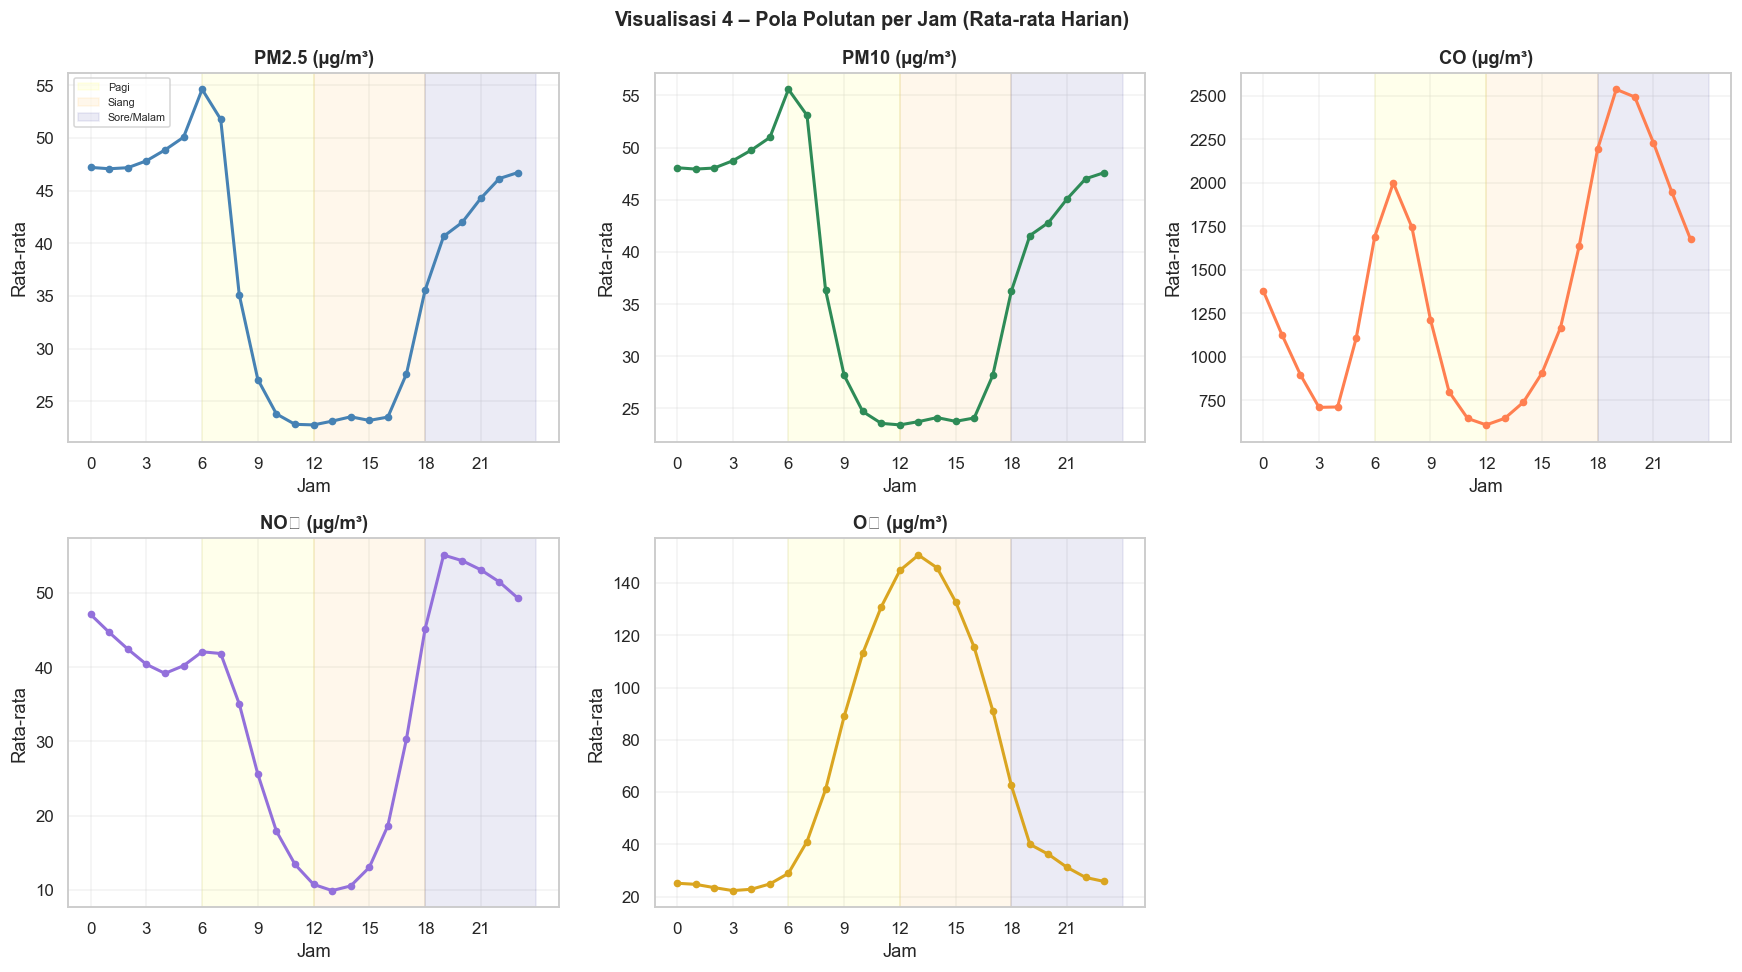

💾 Disimpan → reports/viz4_pola_per_jam.png


In [13]:
# ── Visualisasi 4: Pola jam (rata-rata per jam) ───────────────────
df_raw["hour"] = df_raw["time"].dt.hour

hourly_avg = df_raw.groupby("hour")[polutan_cols].mean()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (col, label) in enumerate(labels_map.items()):
    axes[i].plot(hourly_avg.index, hourly_avg[col],
                 marker="o", color=colors[i], linewidth=2, markersize=4)
    axes[i].axvspan(6, 12,  alpha=0.08, color="yellow", label="Pagi")
    axes[i].axvspan(12, 18, alpha=0.08, color="orange", label="Siang")
    axes[i].axvspan(18, 24, alpha=0.08, color="navy",   label="Sore/Malam")
    axes[i].set_title(label, fontweight="bold")
    axes[i].set_xlabel("Jam")
    axes[i].set_ylabel("Rata-rata")
    axes[i].set_xticks(range(0, 24, 3))
    axes[i].grid(True, alpha=0.25)
    if i == 0:
        axes[i].legend(fontsize=7)

axes[-1].set_visible(False)
plt.suptitle("Visualisasi 4 – Pola Polutan per Jam (Rata-rata Harian)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/viz4_pola_per_jam.png", dpi=110, bbox_inches="tight")
plt.show()
print("💾 Disimpan → reports/viz4_pola_per_jam.png")

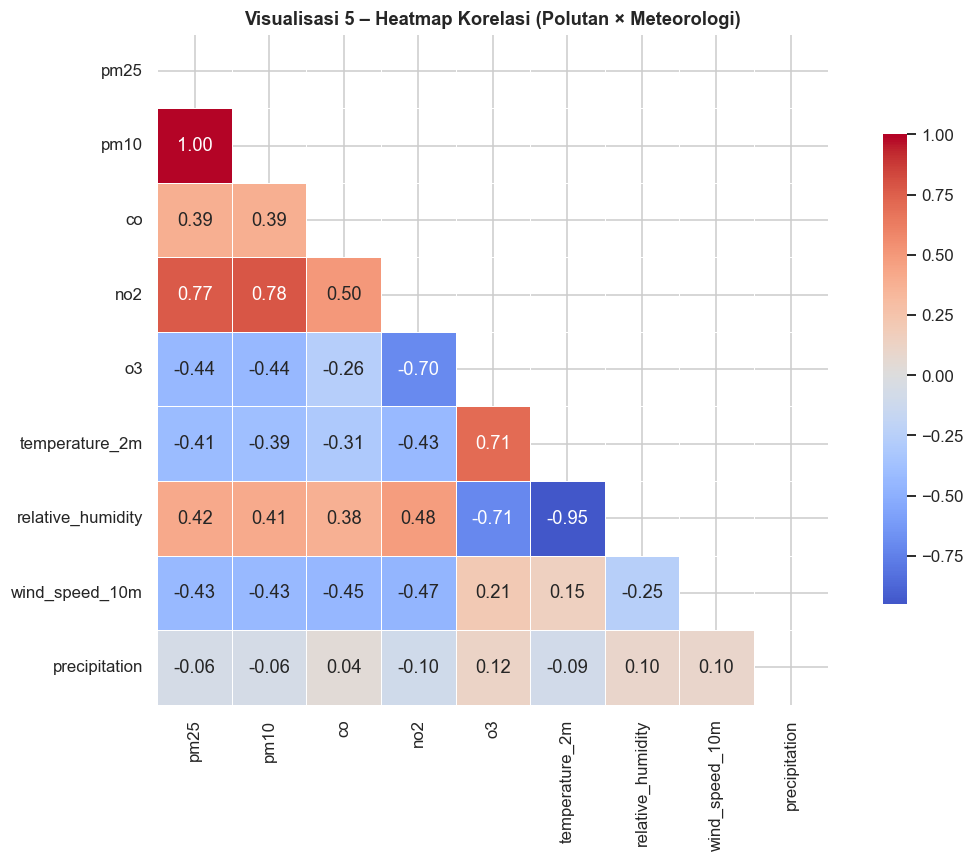

💾 Disimpan → reports/viz5_korelasi_heatmap.png


In [14]:
# ── Visualisasi 5: Korelasi polutan & meteorologi ────────────────
corr_cols = polutan_cols + ["temperature_2m", "relative_humidity",
                             "wind_speed_10m", "precipitation"]
corr = df_raw[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # segitiga atas
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, mask=mask, square=True,
            linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.7})
ax.set_title("Visualisasi 5 – Heatmap Korelasi (Polutan × Meteorologi)",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.savefig("reports/viz5_korelasi_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()
print("💾 Disimpan → reports/viz5_korelasi_heatmap.png")

## 8. Studi Literatur – Formula ISPU KLHK (Permen LHK No. 14 Tahun 2020)

Sistem mengacu pada **Indeks Standar Pencemar Udara (ISPU)** sesuai Permen LHK No. 14/2020.

### Tabel Kategori ISPU

| Rentang ISPU | Kategori       | Warna  | Keterangan |
|:---:|:---|:---|:---|
| 0 – 50       | Baik           | Hijau  | Tidak ada risiko kesehatan |
| 51 – 100     | Sedang         | Biru   | Sedikit mengkhawatirkan untuk kelompok sensitif |
| 101 – 200    | Tidak Sehat    | Kuning | Setiap orang mulai mengalami efek kesehatan |
| 201 – 300    | Sangat Tidak Sehat | Merah | Peringatan darurat, semua terdampak serius |
| > 300        | Berbahaya      | Hitam  | Kondisi darurat, seluruh penduduk terdampak berat |

### Formula Konversi Konsentrasi → ISPU

$$
ISPU = \frac{I_{hi} - I_{lo}}{C_{hi} - C_{lo}} \times (C_a - C_{lo}) + I_{lo}
$$

Di mana:
- $C_a$ = konsentrasi polutan terukur
- $C_{hi}$, $C_{lo}$ = batas atas/bawah konsentrasi pada interval ISPU yang berlaku
- $I_{hi}$, $I_{lo}$ = batas atas/bawah nilai ISPU pada interval tersebut

> **Catatan:** ISPU dihitung per polutan secara terpisah. Nilai ISPU final = nilai tertinggi dari semua polutan.

In [15]:
# ── Implementasi Formula ISPU untuk PM2.5 (preview) ─────────────
# Breakpoint PM2.5 KLHK (µg/m³) → ISPU
PM25_BREAKPOINTS = [
    # (C_lo, C_hi, I_lo, I_hi)
    (0.0,   15.5,   0,  50),
    (15.5,  55.4,  51, 100),
    (55.4, 150.4, 101, 200),
    (150.4, 250.4, 201, 300),
    (250.4, 500.4, 301, 500),
]

def konsentrasi_ke_ispu(konsentrasi, breakpoints):
    """Konversi konsentrasi polutan ke nilai ISPU menggunakan formula Permen LHK 14/2020."""
    if pd.isna(konsentrasi) or konsentrasi < 0:
        return np.nan
    for C_lo, C_hi, I_lo, I_hi in breakpoints:
        if C_lo <= konsentrasi <= C_hi:
            ispu = ((I_hi - I_lo) / (C_hi - C_lo)) * (konsentrasi - C_lo) + I_lo
            return round(ispu, 1)
    return 500.0  # di atas breakpoint tertinggi

def ispu_ke_kategori(ispu):
    """Konversi nilai ISPU ke kategori."""
    if pd.isna(ispu):
        return "N/A"
    if ispu <= 50:  return "Baik"
    elif ispu <= 100: return "Sedang"
    elif ispu <= 200: return "Tidak Sehat"
    elif ispu <= 300: return "Sangat Tidak Sehat"
    else:             return "Berbahaya"

# Uji pada beberapa nilai PM2.5
test_vals = [10, 30, 80, 200, 300]
print("Uji formula ISPU PM2.5:")
print(f"{'Konsentrasi (µg/m³)':>22} | {'ISPU':>8} | {'Kategori'}")
print("-" * 50)
for v in test_vals:
    ispu = konsentrasi_ke_ispu(v, PM25_BREAKPOINTS)
    kategori = ispu_ke_kategori(ispu)
    print(f"{v:>22.1f} | {ispu:>8.1f} | {kategori}")

print("\n✅ Formula ISPU KLHK sudah diverifikasi — siap dipakai di Minggu 2")

Uji formula ISPU PM2.5:
   Konsentrasi (µg/m³) |     ISPU | Kategori
--------------------------------------------------
                  10.0 |     32.3 | Baik
                  30.0 |     68.8 | Sedang
                  80.0 |    126.6 | Tidak Sehat
                 200.0 |    250.1 | Sangat Tidak Sehat
                 300.0 |    340.5 | Berbahaya

✅ Formula ISPU KLHK sudah diverifikasi — siap dipakai di Minggu 2


## 9. Ringkasan EDA Minggu 1

In [16]:
print("=" * 60)
print("RINGKASAN EDA MINGGU 1 – LINDA ANGGARA WATI")
print("=" * 60)

print(f"\n📦 Dataset:")
print(f"   Shape      : {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")
print(f"   Rentang    : {df_raw['time'].min().date()} → {df_raw['time'].max().date()}")
print(f"   File raw   : data/raw/surabaya_airquality_raw.csv")

print(f"\n📊 Statistik Polutan:")
for col, label in labels_map.items():
    col_data = df_raw[col]
    print(f"   {label:<18} | mean={col_data.mean():.2f} | max={col_data.max():.2f} | NaN={col_data.isna().sum()}")

print(f"\n✅ Visualisasi yang dibuat (tersimpan di reports/):")
for i, fname in enumerate([
    "viz1_distribusi_pm25.png",
    "viz2_distribusi_semua_polutan.png",
    "viz3_timeseries_polutan.png",
    "viz4_pola_per_jam.png",
    "viz5_korelasi_heatmap.png",
], 1):
    print(f"   [{i}] {fname}")

print(f"\n📚 Studi Literatur:")
print("   - Formula ISPU PM2.5 (Permen LHK No. 14/2020) → sudah diimplementasi & diverifikasi")
print("   - Breakpoint PM2.5: 5 interval (0–50 | 51–100 | 101–200 | 201–300 | 301–500)")
print("   - Siap dilanjutkan ke: PM10, CO, NO2, O3 di Minggu 2")

print("\n🎯 Tolak Ukur Keberhasilan Minggu 1 (Bagian Linda):")
checklist = [
    "Data historis Jan–Apr 2026 berhasil difetch",
    "Raw data tersimpan di data/raw/",
    "Notebook EDA awal selesai dengan 5 visualisasi",
    "Formula ISPU KLHK sudah dipahami dan dicatat",
]
for item in checklist:
    print(f"   [✅] {item}")

RINGKASAN EDA MINGGU 1 – LINDA ANGGARA WATI

📦 Dataset:
   Shape      : 3,288 baris × 13 kolom
   Rentang    : 2026-01-01 → 2026-05-17
   File raw   : data/raw/surabaya_airquality_raw.csv

📊 Statistik Polutan:
   PM2.5 (µg/m³)      | mean=37.61 | max=148.10 | NaN=0
   PM10 (µg/m³)       | mean=38.45 | max=150.40 | NaN=0
   CO (µg/m³)         | mean=1367.30 | max=8115.00 | NaN=0
   NO₂ (µg/m³)        | mean=34.65 | max=193.40 | NaN=0
   O₃ (µg/m³)         | mean=67.12 | max=284.00 | NaN=0

✅ Visualisasi yang dibuat (tersimpan di reports/):
   [1] viz1_distribusi_pm25.png
   [2] viz2_distribusi_semua_polutan.png
   [3] viz3_timeseries_polutan.png
   [4] viz4_pola_per_jam.png
   [5] viz5_korelasi_heatmap.png

📚 Studi Literatur:
   - Formula ISPU PM2.5 (Permen LHK No. 14/2020) → sudah diimplementasi & diverifikasi
   - Breakpoint PM2.5: 5 interval (0–50 | 51–100 | 101–200 | 201–300 | 301–500)
   - Siap dilanjutkan ke: PM10, CO, NO2, O3 di Minggu 2

🎯 Tolak Ukur Keberhasilan Minggu 1 (Bagia